# 🌍 Country Development Clustering Analysis
### Grouping Countries by Socio-Economic & Health Indicators using Unsupervised Machine Learning

---

## Project Overview

This project analyzes socio-economic and health data for countries around the world and groups them into **clusters** based on their overall level of development.

The dataset was originally compiled for **HELP International**, a humanitarian NGO. The goal is to identify which countries are most in need of aid by grouping countries that share similar economic and health characteristics.

We use **unsupervised machine learning** because the data has no predefined "correct answer" — the algorithms discover natural groupings on their own, purely from patterns in the numbers.

## What This Notebook Covers

1. **Load & Explore** the dataset
2. **Clean the Data** — check and remove duplicate rows and outliers
3. **Visual Analysis** — Univariate, Bivariate, and Multivariate charts
4. **Prepare the Data** for Machine Learning — Encoding & Scaling
5. **Build Three Clustering Models** — K-Means, K-Means + PCA, and Hierarchical Clustering
6. **Compare the Models** using evaluation metrics and pick the best one
7. **Interpret the Results** — explain what each cluster actually means, in plain language

## Dataset Description

| Column | Meaning |
|---|---|
| `country` | Name of the country |
| `child_mort` | Deaths of children under 5 years, per 1,000 live births |
| `exports` | Exports of goods & services, as a % of GDP per capita |
| `health` | Total health spending, as a % of GDP per capita |
| `imports` | Imports of goods & services, as a % of GDP per capita |
| `income` | Net income per person |
| `inflation` | Annual growth rate of the total GDP |
| `life_expec` | Average life expectancy at birth (in years) |
| `total_fer` | Average number of children per woman |
| `gdpp` | GDP per capita (Total GDP ÷ Population) |


---
## Step 1: Import Required Libraries

We begin by importing all the Python libraries needed for this project:

- **pandas, numpy** → for loading and manipulating data
- **matplotlib, seaborn** → for static charts
- **plotly** → for interactive charts (hover, zoom, rotate)
- **scikit-learn** → for scaling, PCA, and clustering algorithms
- **scipy** → for building the hierarchical clustering dendrogram


In [4]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning - Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning - Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

# Machine Learning - Evaluation Metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# For the Hierarchical Clustering Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

# Make all charts look clean and consistent
sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 2: Load the Dataset

We load `Country-data.csv` into a pandas DataFrame called `df`.
Make sure this file is in the same folder as this notebook (or update the file path below).


In [5]:
df = pd.read_csv("/content/Country-data.csv")
print(f"Dataset loaded successfully! It has {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Dataset loaded successfully! It has 167 rows and 10 columns.


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


---
## Step 3: First Look at the Data

Before doing any analysis, it's important to understand the basic structure of the dataset:
its data types, size, and whether anything is missing.


In [6]:
# Data types and non-null counts for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [7]:
# Summary statistics: mean, min, max, quartiles, etc. for every numeric column
df.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


**What this tells us:** the `describe()` table shows the spread of each column.
Notice the huge gap between `income`/`gdpp` mean and max values — this hints that a few
very wealthy countries (like Qatar or Luxembourg) pull the average up. We'll explore this
further in the outlier analysis below.


---
## Step 4: Data Cleaning

Clean data leads to accurate clustering results. We check for three things:

1. **Missing values**
2. **Duplicate rows**
3. **Outliers**


### 4.1 Missing Values


In [8]:
missing_values = df.isna().sum()
print("Missing values per column:")
print(missing_values)

if missing_values.sum() == 0:
    print("\nNo missing values found — the dataset is complete.")

Missing values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

No missing values found — the dataset is complete.


### 4.2 Duplicate Rows

We check for two types of duplicates:
- **Row-wise duplicates**: an entire row that exactly matches another row
- **Duplicate country names**: the same country appearing more than once


In [9]:
# Row-wise duplicates (an entire row repeated)
row_duplicate_count = df.duplicated().sum()
print(f"Fully duplicate rows found: {row_duplicate_count}")

# Duplicate country names
country_duplicate_count = df["country"].duplicated().sum()
print(f"Duplicate country names found: {country_duplicate_count}")

# Remove duplicates, if any are found
df = df.drop_duplicates(keep="first")
df = df.drop_duplicates(subset="country", keep="first")
df = df.reset_index(drop=True)

print(f"\nDataset shape after duplicate removal: {df.shape}")

Fully duplicate rows found: 0
Duplicate country names found: 0

Dataset shape after duplicate removal: (167, 10)


### 4.3 Outliers

Not every "outlier" should be removed. In this dataset:

- **`income`, `gdpp`, `child_mort`, `exports`, `imports`, `inflation`** often contain *real* extreme
  values — for example, very wealthy nations (high income/gdpp), small trade-hub economies
  (high exports/imports), or countries in genuine economic crisis (high inflation). These extreme
  values are exactly what makes clustering useful — **we keep them**.
- **`health`, `life_expec`, `total_fer`** usually fall in a fairly predictable range, so unusual
  values here are more likely to be data-entry issues. We apply outlier removal **only to these
  three columns**, using the IQR (Interquartile Range) method.


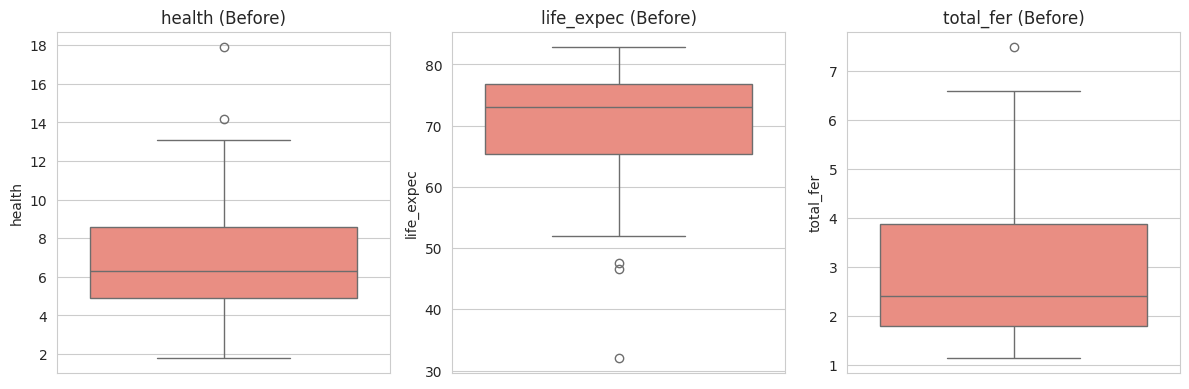

In [10]:
target_cols = ["health", "life_expec", "total_fer"]

# --- Visualize BEFORE removing outliers ---
plt.figure(figsize=(12, 4))
for i, col in enumerate(target_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color="salmon")
    plt.title(f"{col} (Before)")
plt.tight_layout()
plt.show()

In [11]:
# --- Detect outliers using the IQR method ---
bounds = {}
for col in target_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    bounds[col] = (lower, upper)

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col:12s} -> {len(outliers)} outlier(s) | Valid range: [{lower:.2f}, {upper:.2f}]")

# --- Remove the detected outliers ---
before_rows = df.shape[0]
for col in target_cols:
    lower, upper = bounds[col]
    df = df[(df[col] >= lower) & (df[col] <= upper)]
df = df.reset_index(drop=True)

print(f"\nRows before: {before_rows}  |  Rows after: {df.shape[0]}  |  Removed: {before_rows - df.shape[0]}")

health       -> 2 outlier(s) | Valid range: [-0.60, 14.12]
life_expec   -> 3 outlier(s) | Valid range: [48.05, 94.05]
total_fer    -> 1 outlier(s) | Valid range: [-1.33, 7.01]

Rows before: 167  |  Rows after: 161  |  Removed: 6


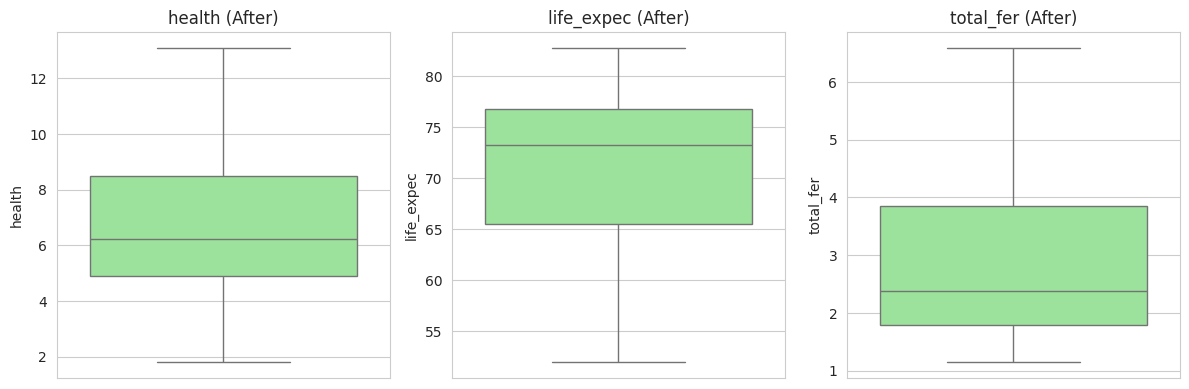

In [12]:
# --- Visualize AFTER removing outliers ---
plt.figure(figsize=(12, 4))
for i, col in enumerate(target_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color="lightgreen")
    plt.title(f"{col} (After)")
plt.tight_layout()
plt.show()

> **Important:** From this point onward, every cell in this notebook uses the
> **cleaned `df`** (duplicates and selected outliers already removed).


---
## Step 5: Exploratory Data Analysis (EDA)

Now that the data is clean, we explore it visually in three ways:

- **Univariate** — looking at *one* column at a time
- **Bivariate** — looking at the relationship between *two* columns
- **Multivariate** — looking at *three or more* columns together


### 5.1 Univariate Analysis


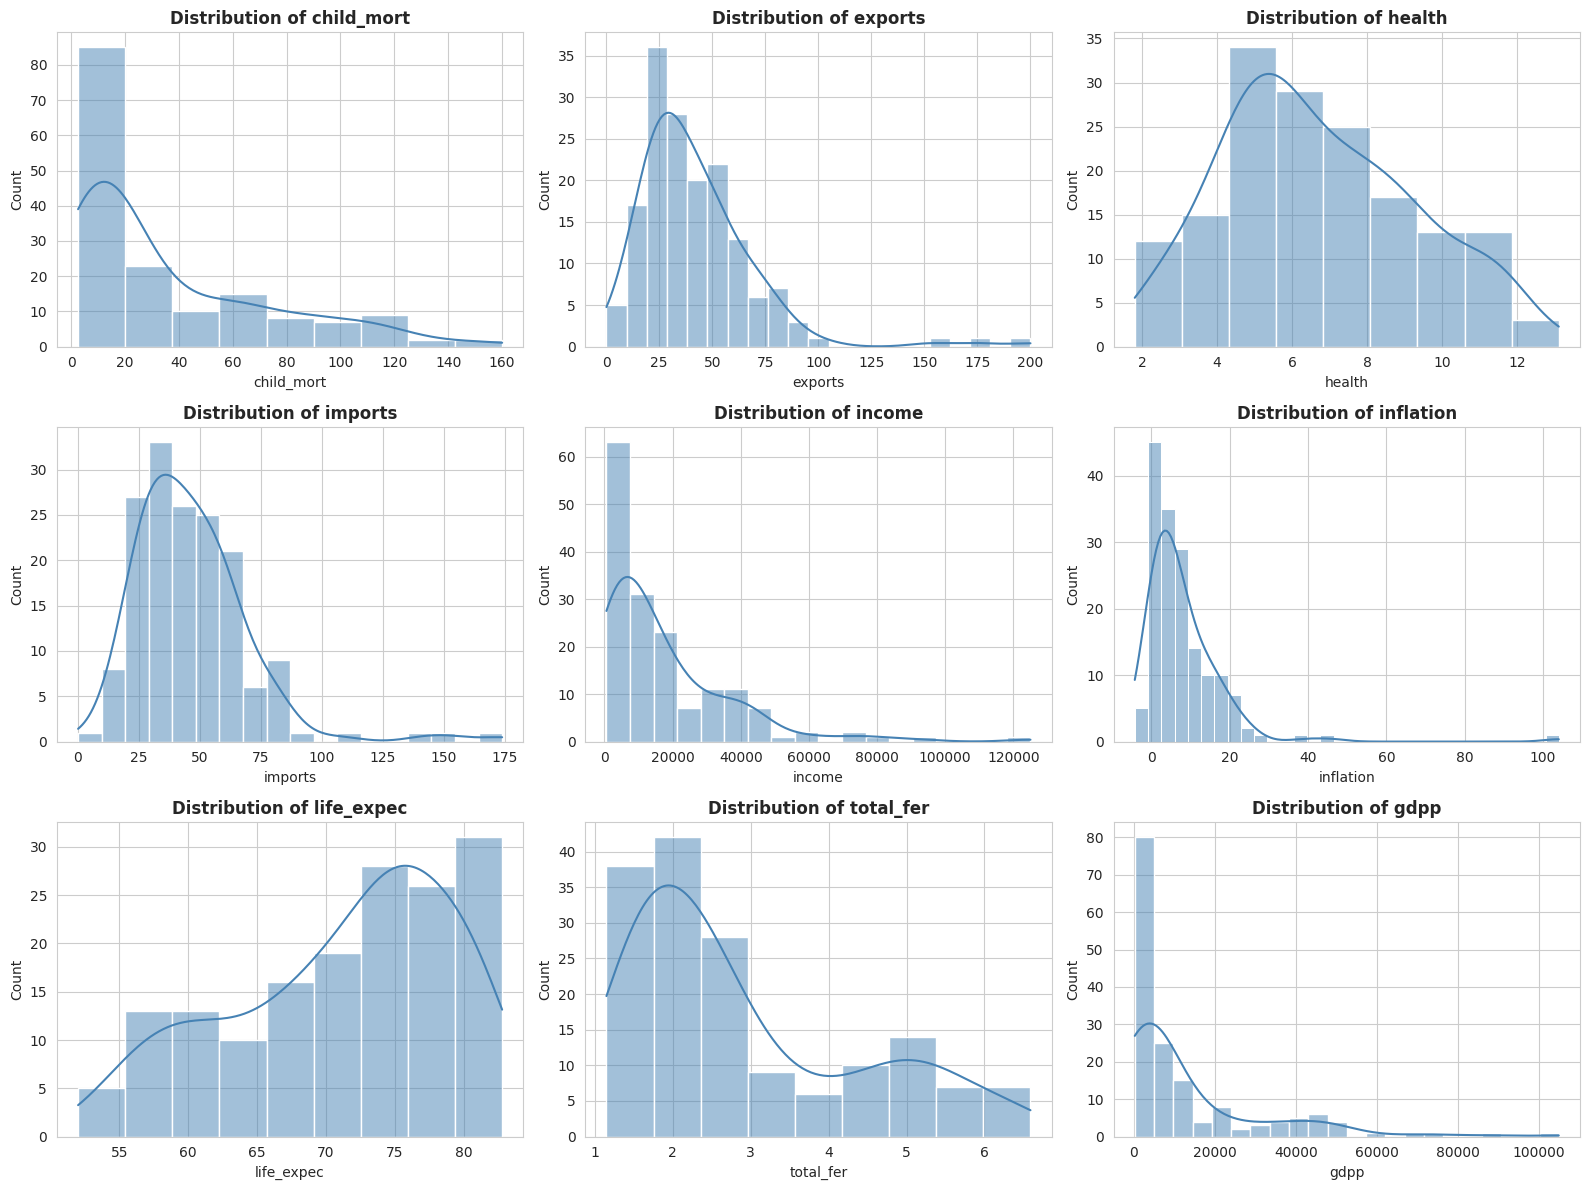

In [13]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()

# Histograms: shows the distribution (shape) of every numeric column
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}", fontweight="bold")
plt.tight_layout()
plt.show()

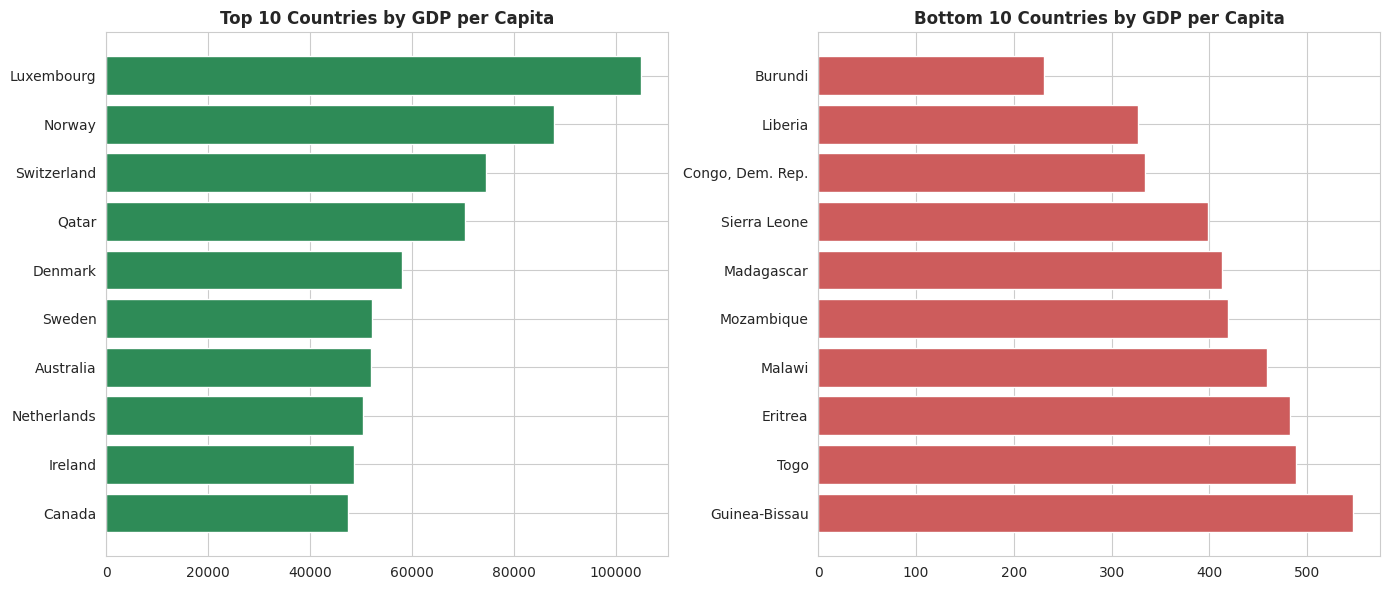

In [14]:
# Top 10 richest and bottom 10 poorest countries by GDP per capita
top10 = df.nlargest(10, "gdpp")[["country", "gdpp"]]
bottom10 = df.nsmallest(10, "gdpp")[["country", "gdpp"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top10["country"], top10["gdpp"], color="seagreen")
axes[0].set_title("Top 10 Countries by GDP per Capita", fontweight="bold")
axes[0].invert_yaxis()

axes[1].barh(bottom10["country"], bottom10["gdpp"], color="indianred")
axes[1].set_title("Bottom 10 Countries by GDP per Capita", fontweight="bold")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
# Interactive histogram: hover over bars to see exact counts
fig = px.histogram(
    df, x="child_mort", nbins=30,
    title="Child Mortality Distribution (Interactive)",
    labels={"child_mort": "Child Mortality (per 1,000 live births)"},
    color_discrete_sequence=["darkorange"]
)
fig.show()

### 5.2 Bivariate Analysis


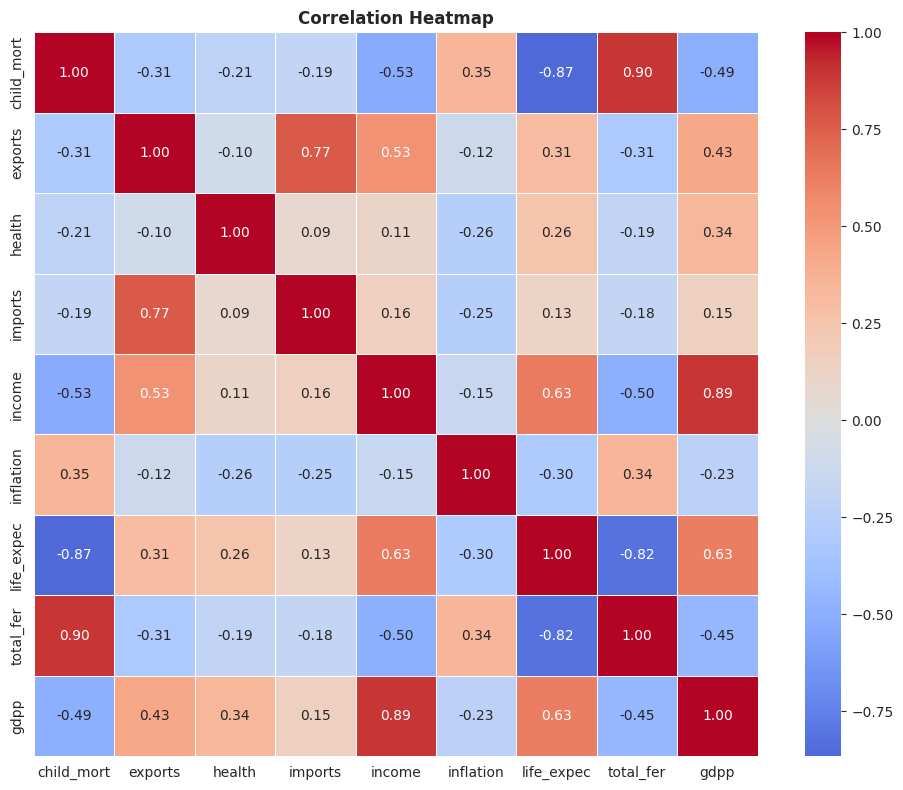

In [16]:
# Correlation heatmap: shows how strongly every pair of columns is related
# (+1 = strong positive relationship, -1 = strong negative relationship, 0 = no relationship)
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Correlation Heatmap", fontweight="bold")
plt.tight_layout()
plt.show()

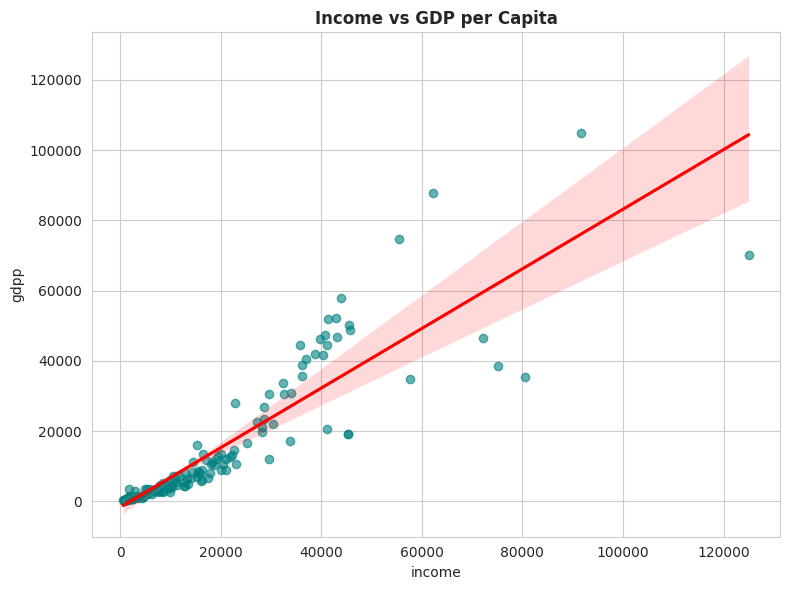

In [17]:
# Income tends to rise together with GDP per capita
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x="income", y="gdpp",
            scatter_kws={"color": "teal", "alpha": 0.6}, line_kws={"color": "red"})
plt.title("Income vs GDP per Capita", fontweight="bold")
plt.tight_layout()
plt.show()

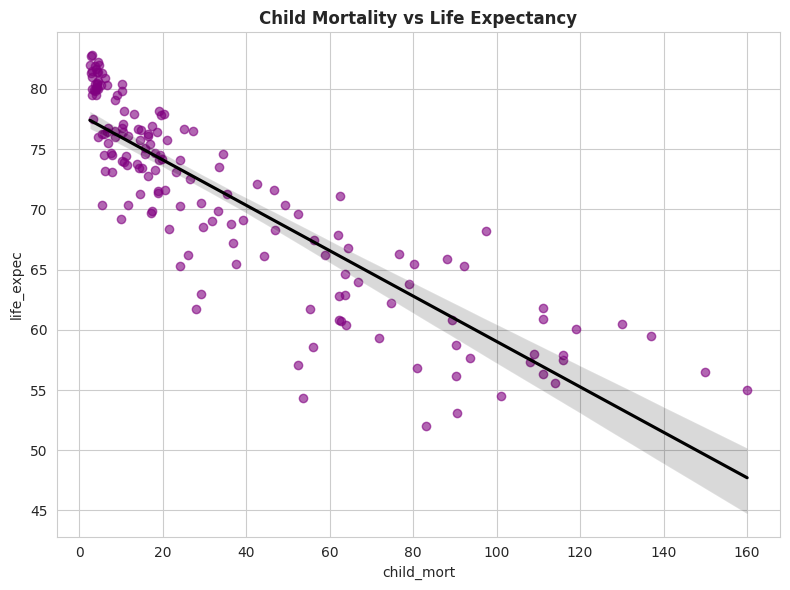

In [18]:
# As child mortality increases, life expectancy decreases (inverse relationship)
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x="child_mort", y="life_expec",
            scatter_kws={"color": "purple", "alpha": 0.6}, line_kws={"color": "black"})
plt.title("Child Mortality vs Life Expectancy", fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
# Interactive scatter plot: hover to see the country name
fig = px.scatter(
    df, x="income", y="life_expec", hover_name="country",
    size="gdpp", color="child_mort", color_continuous_scale="RdYlGn_r",
    title="Income vs Life Expectancy (size = GDP, color = child mortality)"
)
fig.show()

### 5.3 Multivariate Analysis


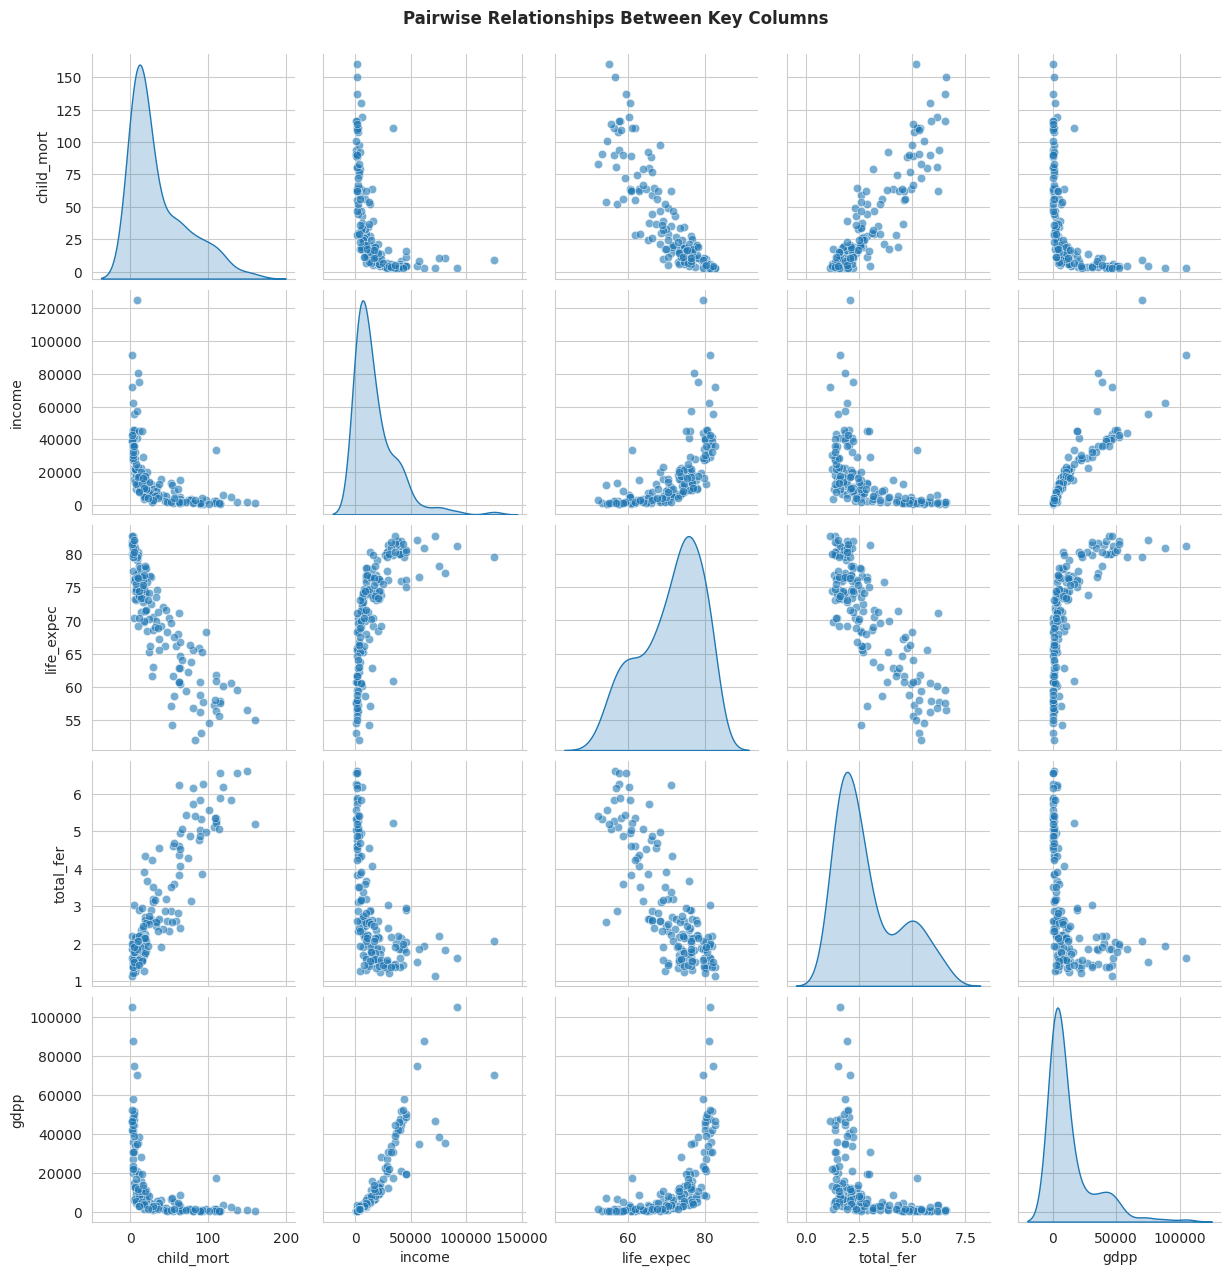

In [20]:
# Pairplot: compares several important columns against each other, all at once
important_cols = ["child_mort", "income", "life_expec", "total_fer", "gdpp"]
pair_fig = sns.pairplot(df[important_cols], diag_kind="kde", plot_kws={"alpha": 0.6})
pair_fig.fig.suptitle("Pairwise Relationships Between Key Columns", y=1.02, fontweight="bold")
plt.show()

In [21]:
# 3D interactive scatter: rotate with your mouse to explore three dimensions at once
fig = px.scatter_3d(
    df, x="income", y="life_expec", z="gdpp",
    color="child_mort", hover_name="country", color_continuous_scale="RdYlGn_r",
    title="3D View: Income, Life Expectancy & GDP per Capita"
)
fig.show()

In [22]:
# Parallel coordinates: every country is drawn as one line crossing ALL columns at once
fig = px.parallel_coordinates(
    df, dimensions=numeric_cols, color="gdpp",
    color_continuous_scale=px.colors.diverging.Tealrose,
    title="Parallel Coordinates — Every Country as One Line"
)
fig.show()

---
## Step 6: Prepare the Data for Machine Learning

Clustering algorithms work with numbers and distances, so we need two preprocessing steps:

1. **Encoding** — handle the one text column (`country`)
2. **Scaling** — put every numeric column on the same scale


### 6.1 Encoding

The `country` column is just a name/identifier — it has no natural numeric order
(there's no sense in which "India > Japan"). Because of this, **we do not use it as a
clustering feature.** We encode it only for reference/display purposes.


In [23]:
le = LabelEncoder()
df["country_encoded"] = le.fit_transform(df["country"])
print("'country' encoded for reference. It will NOT be used as a clustering feature.")

# These are the actual numeric columns we will cluster on
feature_cols = ["child_mort", "exports", "health", "imports",
                 "income", "inflation", "life_expec", "total_fer", "gdpp"]
X = df[feature_cols]
print(f"\nFeatures selected for clustering: {feature_cols}")

'country' encoded for reference. It will NOT be used as a clustering feature.

Features selected for clustering: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


### 6.2 Scaling

K-Means and Hierarchical Clustering both rely on measuring **distance** between data points.
Without scaling, columns like `income` and `gdpp` (which range into the tens of thousands)
would completely dominate columns like `health` (which ranges from roughly 2 to 12).
**`StandardScaler`** transforms every column to have a mean of 0 and a standard deviation of 1,
so all columns contribute fairly.


In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaling complete. Every feature now has mean = 0 and standard deviation = 1.")

Scaling complete. Every feature now has mean = 0 and standard deviation = 1.


---
## Step 7: Model 1 — K-Means Clustering

**K-Means** groups data points into *k* clusters by repeatedly:
1. Placing *k* random cluster centers
2. Assigning every point to its nearest center
3. Moving each center to the average position of its assigned points
4. Repeating steps 2–3 until the centers stop moving

We first need to choose the best value of *k* (number of clusters).


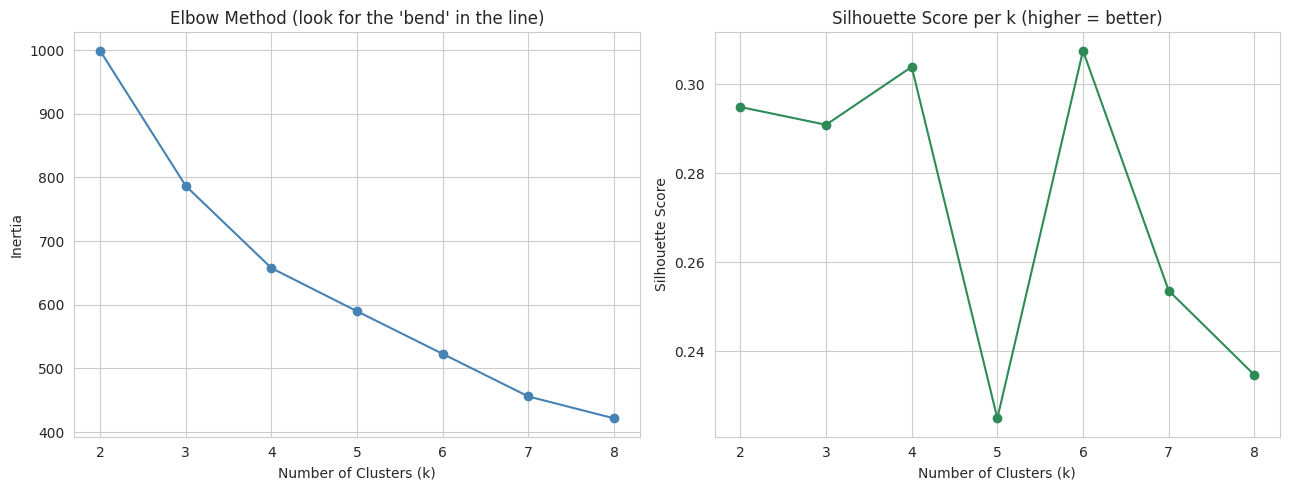

Optimal number of clusters (highest silhouette score): k = 6


In [25]:
# Try k = 2 through 8, and track two scores for each:
#  - Inertia: how tightly packed the clusters are (lower = tighter, used for the "Elbow Method")
#  - Silhouette Score: how well-separated the clusters are (-1 to +1, higher = better)
K_range = range(2, 9)
inertia_list, silhouette_list = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(K_range, inertia_list, marker="o", color="steelblue")
axes[0].set_title("Elbow Method (look for the 'bend' in the line)")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(K_range, silhouette_list, marker="o", color="seagreen")
axes[1].set_title("Silhouette Score per k (higher = better)")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

optimal_k = K_range[int(np.argmax(silhouette_list))]
print(f"Optimal number of clusters (highest silhouette score): k = {optimal_k}")

In [26]:
# Fit the final K-Means model using the optimal k
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X_scaled)
df["KMeans_Cluster"] = kmeans_labels

print(f"K-Means clustering complete — {optimal_k} clusters created.")
print(df["KMeans_Cluster"].value_counts().sort_index())

K-Means clustering complete — 6 clusters created.
KMeans_Cluster
0    79
1    28
2    43
3     1
4     7
5     3
Name: count, dtype: int64


**Visualizing the clusters using the original columns (no PCA)** — this lets us see
directly how real-world features like income and life expectancy define each group.


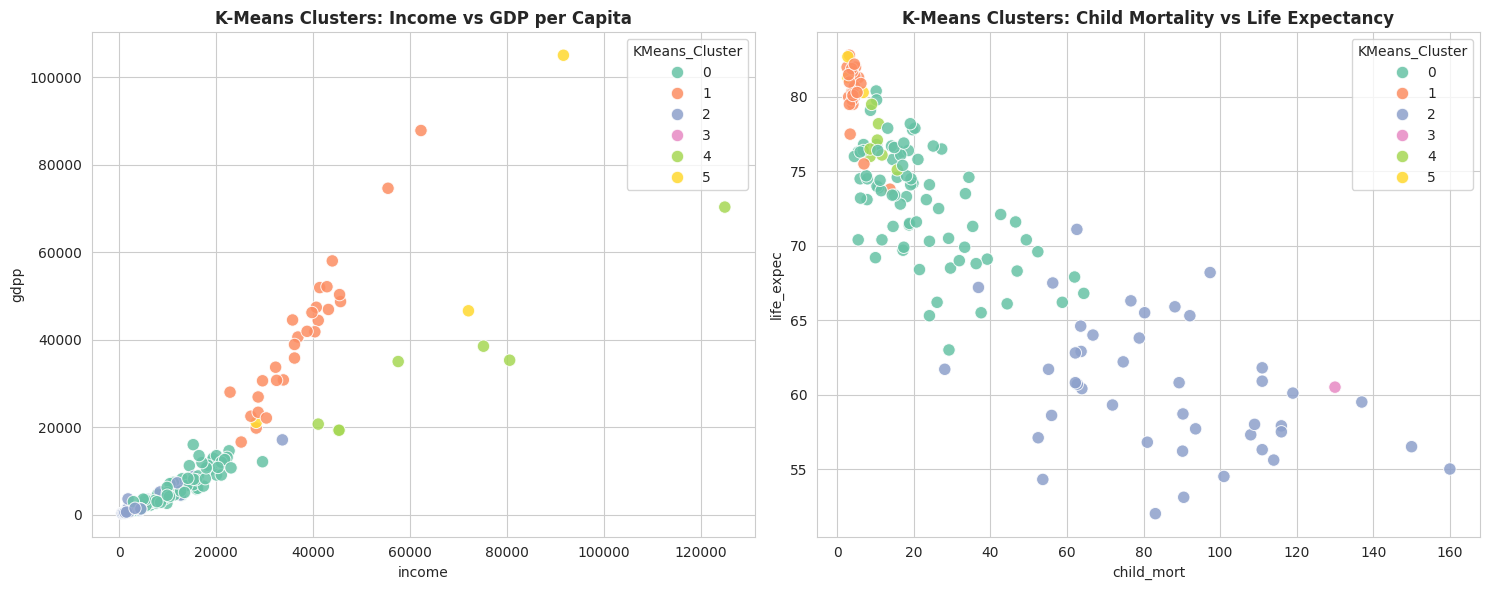

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df, x="income", y="gdpp", hue="KMeans_Cluster",
                 palette="Set2", s=80, alpha=0.85, ax=axes[0])
axes[0].set_title("K-Means Clusters: Income vs GDP per Capita", fontweight="bold")

sns.scatterplot(data=df, x="child_mort", y="life_expec", hue="KMeans_Cluster",
                 palette="Set2", s=80, alpha=0.85, ax=axes[1])
axes[1].set_title("K-Means Clusters: Child Mortality vs Life Expectancy", fontweight="bold")

plt.tight_layout()
plt.show()

---
## Step 8: Model 2 — PCA + K-Means

**PCA (Principal Component Analysis)** compresses our 9 correlated columns into a
small number of new "summary" columns (called *principal components*) that still capture
most of the original information. This makes the data easier to visualize in 2D, and can
sometimes make clustering faster and less noisy.


In [28]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_

print(f"PC1 explains {explained_var[0]*100:.1f}% of the variance")
print(f"PC2 explains {explained_var[1]*100:.1f}% of the variance")
print(f"Together, 2 components capture {explained_var.sum()*100:.1f}% of the original information")

PC1 explains 47.2% of the variance
PC2 explains 17.2% of the variance
Together, 2 components capture 64.4% of the original information


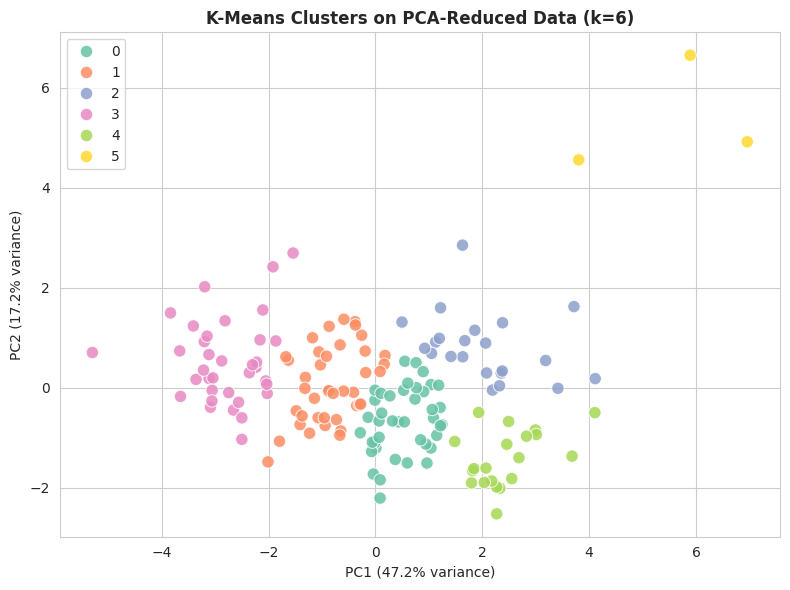

In [29]:
# Run K-Means again, this time on the PCA-reduced data (using the same optimal_k)
kmeans_pca_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_pca_labels = kmeans_pca_model.fit_predict(X_pca)
df["KMeans_PCA_Cluster"] = kmeans_pca_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_pca_labels, palette="Set2", s=80, alpha=0.85)
plt.title(f"K-Means Clusters on PCA-Reduced Data (k={optimal_k})", fontweight="bold")
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% variance)")
plt.tight_layout()
plt.show()

---
## Step 9: Model 3 — Hierarchical Clustering

**Hierarchical Clustering** builds a tree of clusters from the bottom up: it starts by
treating every country as its own cluster, then repeatedly merges the two closest
clusters until only one remains. The result is visualized as a **dendrogram** — a tree
diagram showing the order in which countries were merged.


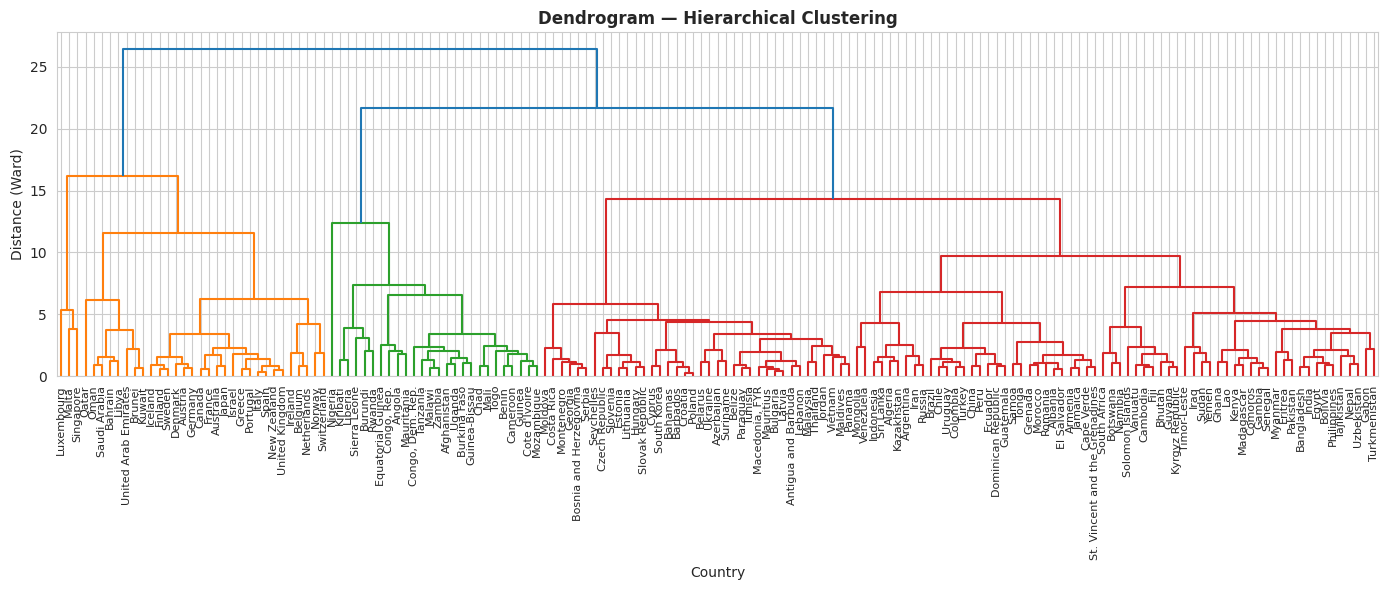

In [30]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linked, labels=df["country"].values, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrogram — Hierarchical Clustering", fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Distance (Ward)")
plt.tight_layout()
plt.show()

In [31]:
# Cut the tree into the same number of clusters (optimal_k) for a fair comparison
hier_model = AgglomerativeClustering(n_clusters=optimal_k, linkage="ward")
hier_labels = hier_model.fit_predict(X_scaled)
df["Hierarchical_Cluster"] = hier_labels

print(f"Hierarchical clustering complete — {optimal_k} clusters created.")
print(df["Hierarchical_Cluster"].value_counts().sort_index())

Hierarchical clustering complete — 6 clusters created.
Hierarchical_Cluster
0    30
1    25
2    64
3     3
4    38
5     1
Name: count, dtype: int64


---
## Step 10: Compare All Three Models

We now measure each model using three standard clustering evaluation metrics,
all calculated on the same original scaled data for a fair comparison:

| Metric | What it Measures | Better When... |
|---|---|---|
| **Silhouette Score** | How well-separated the clusters are | Higher (closer to +1) |
| **Davies-Bouldin Index** | How similar/overlapping clusters are | Lower (closer to 0) |
| **Calinski-Harabasz Score** | Ratio of between-cluster to within-cluster variance | Higher |


In [32]:
comparison = {
    "Model": ["K-Means", "K-Means + PCA", "Hierarchical Clustering"],
    "Silhouette (higher=better)": [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, kmeans_pca_labels),
        silhouette_score(X_scaled, hier_labels),
    ],
    "Davies-Bouldin (lower=better)": [
        davies_bouldin_score(X_scaled, kmeans_labels),
        davies_bouldin_score(X_scaled, kmeans_pca_labels),
        davies_bouldin_score(X_scaled, hier_labels),
    ],
    "Calinski-Harabasz (higher=better)": [
        calinski_harabasz_score(X_scaled, kmeans_labels),
        calinski_harabasz_score(X_scaled, kmeans_pca_labels),
        calinski_harabasz_score(X_scaled, hier_labels),
    ],
}
results_df = pd.DataFrame(comparison)
results_df

,Model,Silhouette (higher=better),Davies-Bouldin (lower=better),Calinski-Harabasz (higher=better)
0,K-Means,0.307483,0.850847,54.926457
1,K-Means + PCA,0.186061,1.462074,47.210403
2,Hierarchical Clustering,0.188636,1.063558,50.070714


In [33]:
# Rank each model on every metric, then average the ranks (lowest average rank = best overall)
results_df["Rank_Silhouette"] = results_df["Silhouette (higher=better)"].rank(ascending=False)
results_df["Rank_DaviesBouldin"] = results_df["Davies-Bouldin (lower=better)"].rank(ascending=True)
results_df["Rank_CalinskiHarabasz"] = results_df["Calinski-Harabasz (higher=better)"].rank(ascending=False)
results_df["Average_Rank"] = results_df[["Rank_Silhouette", "Rank_DaviesBouldin", "Rank_CalinskiHarabasz"]].mean(axis=1)

best_model = results_df.loc[results_df["Average_Rank"].idxmin(), "Model"]

print("="*60)
print(f"BEST MODEL: {best_model}")
print("="*60)
results_df[["Model", "Average_Rank"]]

BEST MODEL: K-Means


,Model,Average_Rank
0,K-Means,1.0
1,K-Means + PCA,3.0
2,Hierarchical Clustering,2.0


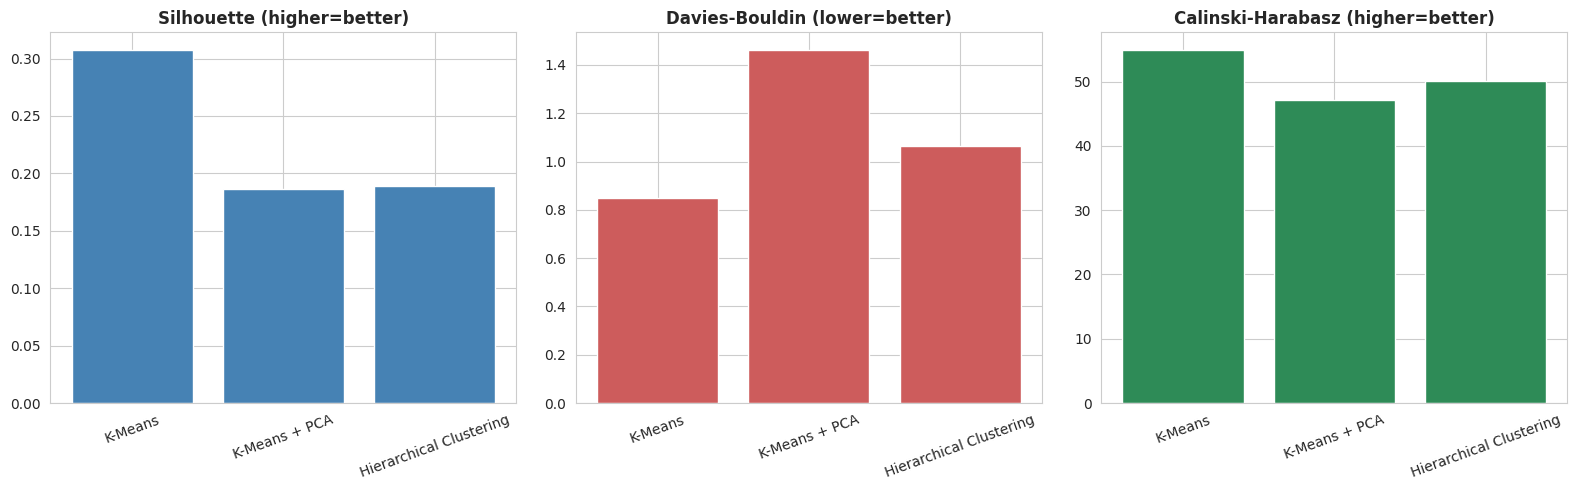

In [34]:
# Visual comparison of all three metrics, side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metric_cols = ["Silhouette (higher=better)", "Davies-Bouldin (lower=better)", "Calinski-Harabasz (higher=better)"]
colors = ["steelblue", "indianred", "seagreen"]

for ax, col, color in zip(axes, metric_cols, colors):
    ax.bar(results_df["Model"], results_df[col], color=color)
    ax.set_title(col, fontweight="bold")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

---
## Step 11: What Do the Clusters Actually Mean?

A clustering result is only useful if we can explain it in plain language. Using the
**best model's** cluster labels, we look at the average value of each feature per
cluster, and rank the clusters from least to most developed (based on GDP per capita).


In [35]:
# Map the best model's name to its cluster column
model_to_column = {
    "K-Means": "KMeans_Cluster",
    "K-Means + PCA": "KMeans_PCA_Cluster",
    "Hierarchical Clustering": "Hierarchical_Cluster",
}
best_cluster_col = model_to_column[best_model]
print(f"Using cluster labels from: {best_model}  (column: {best_cluster_col})")

# Average feature values per cluster
cluster_profile = df.groupby(best_cluster_col)[feature_cols].mean().round(2)
cluster_profile

Using cluster labels from: K-Means  (column: KMeans_Cluster)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,21.93,39.97,6.12,46.93,11581.65,7.54,72.97,2.26,6001.42
1,4.52,45.20,9.67,43.39,37360.71,1.15,80.29,1.74,40603.57
2,85.76,30.36,6.43,42.13,4100.95,10.55,60.42,4.99,2015.95
3,130.00,25.30,5.07,17.40,5150.00,104.00,60.50,5.84,2330.00
4,10.70,65.56,3.28,38.70,67171.43,12.52,76.93,2.29,34057.14
5,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67


In [36]:
# Assign a human-readable development tier to each cluster, based on average gdpp
gdpp_order = cluster_profile["gdpp"].sort_values().index.tolist()
n = len(gdpp_order)

tier_library = {
    2: ["Lower Development", "Higher Development"],
    3: ["Underdeveloped (Needs Most Aid)", "Developing", "Developed"],
    4: ["Underdeveloped (Needs Most Aid)", "Developing", "Emerging", "Developed"],
    5: ["Underdeveloped (Needs Most Aid)", "Developing", "Emerging", "Advanced", "Developed"],
}
tier_names = tier_library.get(n, [f"Development Tier {i+1} of {n} (1=Lowest GDP)" for i in range(n)])

tier_map = dict(zip(gdpp_order, tier_names))
df["Development_Tier"] = df[best_cluster_col].map(tier_map)

print("Cluster -> Development Tier mapping:")
for cluster_id, tier in tier_map.items():
    print(f"  Cluster {cluster_id}  ->  {tier}")

Cluster -> Development Tier mapping:
  Cluster 2  ->  Development Tier 1 of 6 (1=Lowest GDP)
  Cluster 3  ->  Development Tier 2 of 6 (1=Lowest GDP)
  Cluster 0  ->  Development Tier 3 of 6 (1=Lowest GDP)
  Cluster 4  ->  Development Tier 4 of 6 (1=Lowest GDP)
  Cluster 1  ->  Development Tier 5 of 6 (1=Lowest GDP)
  Cluster 5  ->  Development Tier 6 of 6 (1=Lowest GDP)


In [37]:
# List which countries fall into each development tier
for tier in tier_names:
    countries_in_tier = df[df["Development_Tier"] == tier]["country"].tolist()
    print(f"\n{tier}  ({len(countries_in_tier)} countries):")
    print(", ".join(countries_in_tier))


Development Tier 1 of 6 (1=Lowest GDP)  (43 countries):
Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Equatorial Guinea, Eritrea, Gabon, Gambia, Ghana, Guinea, Guinea-Bissau, Iraq, Kenya, Kiribati, Lao, Liberia, Madagascar, Malawi, Mali, Mauritania, Mozambique, Namibia, Pakistan, Rwanda, Senegal, Sierra Leone, Solomon Islands, South Africa, Sudan, Tanzania, Timor-Leste, Togo, Uganda, Yemen, Zambia

Development Tier 2 of 6 (1=Lowest GDP)  (1 countries):
Nigeria

Development Tier 3 of 6 (1=Lowest GDP)  (79 countries):
Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bangladesh, Barbados, Belarus, Belize, Bhutan, Bolivia, Bosnia and Herzegovina, Brazil, Bulgaria, Cambodia, Cape Verde, Chile, China, Colombia, Costa Rica, Croatia, Dominican Republic, Ecuador, Egypt, El Salvador, Estonia, Fiji, Georgia, Grenada, Guatemala, Guyana, Hungary, India, Indonesia, Iran, Jamaica, Jordan, Kaza

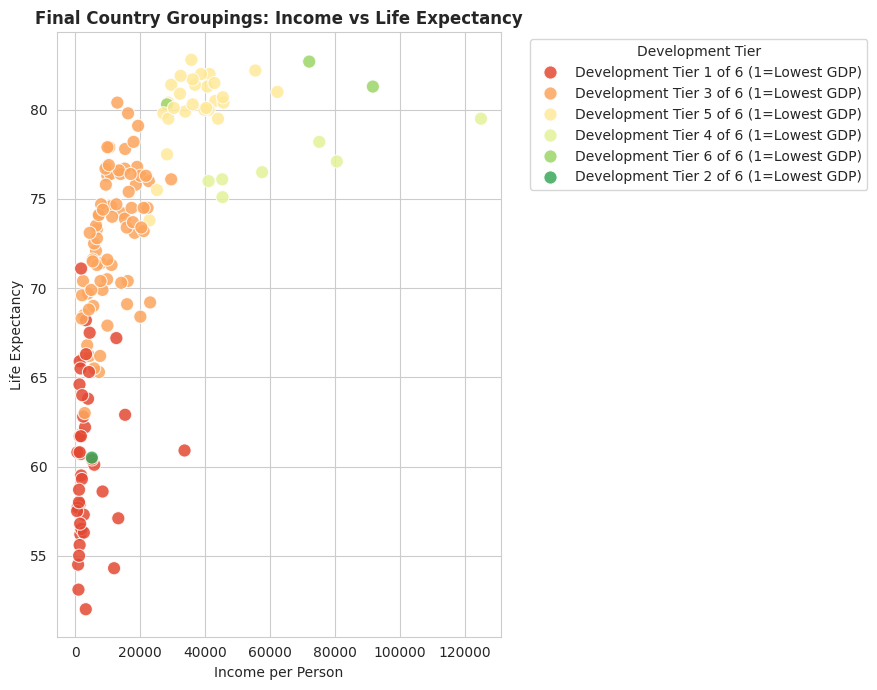

In [38]:
# Visualize the final tiers using real-world features
plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x="income", y="life_expec", hue="Development_Tier",
                 palette="RdYlGn", s=90, alpha=0.85)
plt.title("Final Country Groupings: Income vs Life Expectancy", fontweight="bold")
plt.xlabel("Income per Person")
plt.ylabel("Life Expectancy")
plt.legend(title="Development Tier", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

---
## Conclusion

**Summary of this project:**

1. We cleaned the dataset by removing duplicate rows and statistical outliers in `health`,
   `life_expec`, and `total_fer` (while intentionally keeping real extreme values in `income`,
   `gdpp`, and `child_mort`, since these represent genuine differences between countries).
2. We explored the data visually and found strong relationships — for example, higher income
   is strongly linked with higher GDP per capita, and higher child mortality is strongly linked
   with lower life expectancy.
3. We built **three clustering models** — K-Means, K-Means with PCA, and Hierarchical Clustering
   — and compared them using the Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Score.
4. The **best-performing model** was determined automatically above (see Step 10).
5. Finally, we translated the clusters into **human-readable development tiers**, and listed
   exactly which countries belong to each tier.

**Practical takeaway:** the countries in the *"Underdeveloped (Needs Most Aid)"* tier are the
ones that an organization like HELP International should prioritize for support, since they
share a combination of high child mortality, low income, low life expectancy, and low GDP
per capita.
